<a href="https://colab.research.google.com/github/abhishek-marathe04/makemore/blob/main/building_makemore_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [299]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

## We will be following this paper https://jmlr.org/papers/volume3/tmp/bengio03a.pdf

In [300]:
import requests

url = "https://raw.githubusercontent.com/abhishek-marathe04/makemore/refs/heads/main/Indian_names_kaggle.txt"
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    words = response.text.replace(".", "").lower().splitlines()
    print(f"Downloaded {len(words)} names.")
    # print(words[:100])  # Show first 100 characters
else:
    print("Failed to download the file.")

Downloaded 55689 names.


In [301]:
words[:10]

['aaban',
 'aabharan',
 'aabhas',
 'aabhat',
 'aabheer',
 'aabheer',
 'abheer',
 'aabher',
 'aabi',
 'aabilesh']

In [302]:
# Build the vocabulary of characters and mappings to/from integers
# print(sorted(list(set(''.join(words)))))
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [303]:
import torch

block_size = 3
X = []
Y = []
for w in words:

  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)

    # print(''.join(itos[i] for i in context) ,' -->', itos[ix])
    context = context[1:] + [ix]


X = torch.tensor(X)
Y = torch.tensor(Y)

In [304]:
X.shape, Y.shape

(torch.Size([505438, 3]), torch.Size([505438]))

In [305]:
C = torch.randn(27,2)

In [306]:
C[5]

tensor([-2.7015,  1.3732])

In [307]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([-2.7015,  1.3732])

In [308]:
C[X]

tensor([[[-1.0525, -1.8845],
         [-1.0525, -1.8845],
         [-1.0525, -1.8845]],

        [[-1.0525, -1.8845],
         [-1.0525, -1.8845],
         [-1.5562,  1.0564]],

        [[-1.0525, -1.8845],
         [-1.5562,  1.0564],
         [-1.5562,  1.0564]],

        ...,

        [[ 1.5841,  2.2622],
         [-0.9995,  0.1010],
         [-1.5562,  1.0564]],

        [[-0.9995,  0.1010],
         [-1.5562,  1.0564],
         [ 1.4939, -1.9310]],

        [[-1.5562,  1.0564],
         [ 1.4939, -1.9310],
         [-1.5562,  1.0564]]])

In [309]:
C[X].shape

torch.Size([505438, 3, 2])

In [310]:
X[13,2]

tensor(1)

In [311]:
C[X[13,2]]

tensor([-1.5562,  1.0564])

In [312]:
C[1]

tensor([-1.5562,  1.0564])

In [313]:
emb = C[X]
emb.shape

torch.Size([505438, 3, 2])

In [314]:
w1 = torch.randn(6,100)
b1 = torch.randn(100)

In [315]:
# emb @ w1
# RuntimeError: mat1 and mat2 shapes cannot be multiplied (111x2 and 6x100)

In [316]:
(emb.view(-1,6) @ w1) + b1

tensor([[ 8.1808,  1.3582,  2.7696,  ..., -9.3169, -2.4550, -0.4094],
        [ 7.9555, -5.0005, -0.3772,  ..., -6.4419, -5.2249, -1.7710],
        [ 7.7746, -4.3392,  0.2890,  ..., -5.2444, -3.2325, -4.6375],
        ...,
        [-7.1506, -1.2170,  0.6677,  ...,  6.7119,  0.3349,  1.8805],
        [ 1.1883,  4.2515,  0.6908,  ...,  0.5831,  1.0152, -4.0794],
        [ 4.9416, -5.1605, -0.7187,  ...,  1.9645, -3.8334, -1.0218]])

In [317]:
h = torch.tanh((emb.view(X.shape[0],6) @ w1) + b1) # Hidden layer activation

In [318]:
h.shape

torch.Size([505438, 100])

In [319]:
# Lets create final layer
# Input is 100 from hidden layer, and output is 27 possible characters
w2 = torch.randn(100,27)
b2 = torch.randn(27)
logits = h @ w2 + b2

In [320]:
logits.shape

torch.Size([505438, 27])

In [321]:
# We will apply softmax
counts = logits.exp()

In [322]:
prob = counts / counts.sum(1, keepdim=True)

In [323]:
prob.shape

torch.Size([505438, 27])

In [324]:
prob[1].sum()

tensor(1.0000)

In [325]:
torch.arange(32), Y

(tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
         18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 tensor([ 1,  1,  2,  ..., 11,  1,  0]))

In [326]:
prob[torch.arange(X.shape[0]), Y]

tensor([1.8811e-07, 1.1105e-07, 2.0211e-13,  ..., 9.9999e-01, 2.0093e-10,
        2.4116e-05])

In [327]:
loss = -prob[torch.arange(X.shape[0]), Y].log().mean()
loss

tensor(16.4645)

In [328]:
F.cross_entropy(logits, Y)

tensor(16.4645)

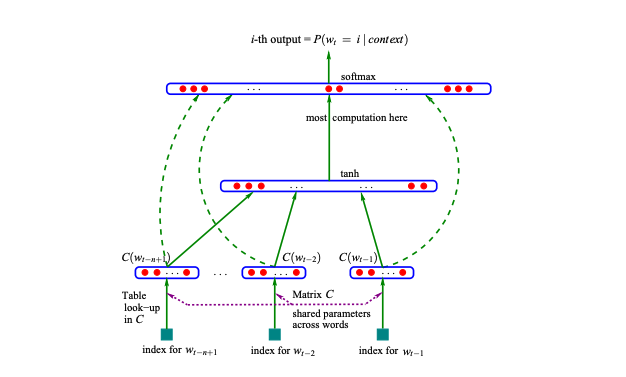

In [329]:
# --------- now made respectable -------

 We will be replicating above neural network where there will be 3 inputs, all will be get indexed to C which is our embedding array. We are storing all characters embedding in 2 dimention format so it will be (27,2) shape.
 Output of this layer would be 6 (2 from each neuron)

 It will then be an input to hidden layer. Our hidden layer will be formed by

> emb * W1 + b1




In [330]:
X.shape, Y.shape

(torch.Size([505438, 3]), torch.Size([505438]))

In [331]:
def initilise_model(hidden_layers=100, embedding_dims=2, input_values=27, output_values=27):

  g = torch.Generator().manual_seed(2147483647) # for reproducability
  C = torch.randn(input_values, embedding_dims, generator=g, requires_grad=True)
  W1 = torch.randn(embedding_dims * 3, hidden_layers,generator=g, requires_grad=True)
  b1 = torch.randn(hidden_layers, generator=g, requires_grad=True)
  W2 = torch.randn(hidden_layers, output_values, generator=g, requires_grad=True)
  b2 = torch.randn(output_values, generator=g, requires_grad=True)
  parameters = [C, W1, b1, W2, b2]
  print("Model initilised..")
  print(f"Hidden Layers : {hidden_layers}, embedding_dims : {embedding_dims}, input_values {input_values}, output_values: {output_values}")
  print(f"Number of parameters in model {sum(p.nelement() for p in parameters)}") # Number of parameters in model
  return C, W1, b1, W2, b2, parameters


In [332]:
# emb = C[X] # (37,3, 2)
# h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (37,100)
# logits = h @ W2 + b2 # 37,27
# # counts = logits.exp()
# # prob = counts / counts.sum(1, keepdim=True)
# # loss = -prob[torch.arange(37), Y].log().mean()
# loss = F.cross_entropy(logits, Y)
# loss

We should always use cross entrophy from pytorch instead of our own implemention

Below are few reasons

* Model outputs logits (raw, unnormalized scores), not probabilities.
* Manual softmax can break for large logits, e.g. [100, 0, -100] → exp(100) overflows → inf / nan.

* Computing softmax and log manually can cause numerical instability (overflow → inf / nan).

* F.cross_entropy fuses log_softmax + negative log-likelihood using a numerically stable formulation.

* It is faster, more memory-efficient, and produces cleaner gradients.

* Rule: if your model outputs logits, pass them directly to F.cross_entropy — never apply softmax yourself.

In [333]:
# for p in parameters:
#   p.requires_grad = True

In [334]:
# torch.randint(0,X.shape[0], (500,)) # We will form minibatch using this

In [335]:
# Lets identify good learning rate
lre = torch.linspace(-3, 0, 1000)

lrs = 10**lre
# for i in range(10):
#     print(lrs[i].item())
# lrs

In [336]:
C, W1, b1, W2, b2, parameters = initilise_model()

Model initilised..
Hidden Layers : 100, embedding_dims : 2, input_values 27, output_values: 27
Number of parameters in model 3481


In [337]:
lri = []
lossi = []
for i in range(1000):
  # Forward pass

  ix = torch.randint(0,X.shape[0], (50,)) # We will form minibatch using this

  emb = C[X[ix]] # (37,3, 2)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (37,100)
  logits = h @ W2 + b2 # 37,27
  loss = F.cross_entropy(logits, Y[ix])
  # loss
  # print(loss.item())
  # Backward pass
  for p in parameters:
    p.grad = None

  loss.backward()

  lr = lrs[i]
  # Update parameters
  for p in parameters:
      p.data += -lr * p.grad

  # Track loss and lr
  lossi.append(loss.item())
  lri.append(lre[i])


print(loss)

tensor(5.0836, grad_fn=<NllLossBackward0>)


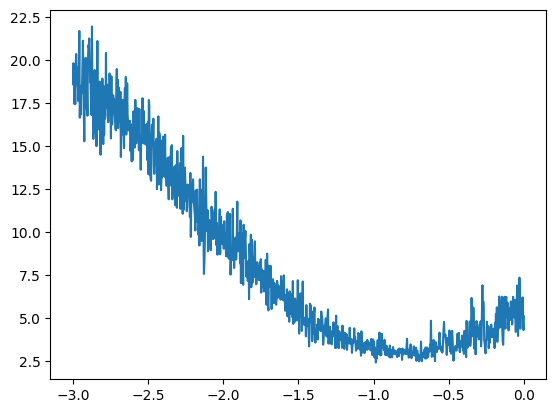

In [338]:
plt.plot(lri, lossi)

From Above Graph, it is clear that good learning exponent is around -1.0 or or 0.1

In [339]:
# Let again initilise everything, Now we know, we will use 0.1 learning rate

C, W1, b1, W2, b2, parameters = initilise_model()

Model initilised..
Hidden Layers : 100, embedding_dims : 2, input_values 27, output_values: 27
Number of parameters in model 3481


In [340]:
# Lets run for 30000 iterations
for i in range(30000):
  # Forward pass

  ix = torch.randint(0,X.shape[0], (100,)) # We will form minibatch using this

  emb = C[X[ix]] # (37,3, 2)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (37,100)
  logits = h @ W2 + b2 # 37,27
  # loss
  loss = F.cross_entropy(logits, Y[ix])

  # Backward pass
  for p in parameters:
    p.grad = None

  loss.backward()

  lr = 0.1 if i < 20000 else 0.01
  # Update parameters
  for p in parameters:
      p.data += -lr * p.grad


print(loss)

tensor(2.0934, grad_fn=<NllLossBackward0>)


In [341]:
  # Print loss for all of X
emb = C[X] # (37,3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (37,100)
logits = h @ W2 + b2 # 37,27
loss = F.cross_entropy(logits, Y)
loss

tensor(2.1504, grad_fn=<NllLossBackward0>)

Lets try to split our dataset into training set, dev/evaluation set, test set
80%, 10%, 10%

In [342]:
import torch
import random

def build_dataset(words):
  print(len(words))
  block_size = 3
  X = []
  Y = []
  for w in words:

    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)

      # print(''.join(itos[i] for i in context) ,' -->', itos[ix])
      context = context[1:] + [ix]


  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y


random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

44551
5569
5569


In [343]:
Xtr.shape, Xdev.shape, Xte.shape

(torch.Size([404248, 3]), torch.Size([50470, 3]), torch.Size([50720, 3]))

In [352]:
# Lets use train set to train our model and eval/dev set to evaluate
# Initlise model again
C, W1, b1, W2, b2, parameters = initilise_model()

Model initilised..
Hidden Layers : 100, embedding_dims : 2, input_values 27, output_values: 27
Number of parameters in model 3481


In [353]:
# Lets run for 30000 iterations on XTr (Xtrain)
for i in range(30000):
  # Forward pass

  ix = torch.randint(0,Xtr.shape[0], (100,)) # We will form minibatch using this

  emb = C[Xtr[ix]] # (37,3, 2)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (37,100)
  logits = h @ W2 + b2 # 37,27
  # loss
  loss = F.cross_entropy(logits, Ytr[ix])

  # Backward pass
  for p in parameters:
    p.grad = None

  loss.backward()

  lr = 0.1 if i < 20000 else 0.01
  # Update parameters
  for p in parameters:
      p.data += -lr * p.grad


print(loss)

tensor(2.3287, grad_fn=<NllLossBackward0>)


In [354]:
# Lets evaluate now on Xdev
  # Print loss for all of Xdev
emb = C[Xdev] # (37,3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (37,100)
logits = h @ W2 + b2 # 37,27
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1501, grad_fn=<NllLossBackward0>)

In [358]:
C

tensor([[ 0.7851, -0.2007],
        [ 0.4395, -0.5454],
        [-0.4794, -0.3977],
        [-1.1685,  0.2530],
        [-0.3843, -0.4660],
        [ 0.1657, -0.6021],
        [-0.2133, -0.1866],
        [ 0.0990,  1.7480],
        [-0.3323, -0.2693],
        [ 0.3031, -0.3973],
        [-0.3426, -0.1147],
        [-0.3114, -0.3151],
        [ 0.1815,  1.7778],
        [-0.2942, -0.1188],
        [-0.1315,  0.0313],
        [ 0.1707, -0.5547],
        [-0.3209, -0.3324],
        [-0.1645, -0.2800],
        [-0.2302, -0.1247],
        [-0.4011, -0.5605],
        [-0.4608, -0.5666],
        [ 0.5064,  0.9698],
        [-0.4309,  0.0287],
        [-0.3976, -0.2365],
        [-0.0522, -0.4308],
        [-0.3500, -0.2367],
        [-0.4627, -0.5045]], requires_grad=True)

In [357]:
C[:,0].data, C[:,1].data

(tensor([ 0.7851,  0.4395, -0.4794, -1.1685, -0.3843,  0.1657, -0.2133,  0.0990,
         -0.3323,  0.3031, -0.3426, -0.3114,  0.1815, -0.2942, -0.1315,  0.1707,
         -0.3209, -0.1645, -0.2302, -0.4011, -0.4608,  0.5064, -0.4309, -0.3976,
         -0.0522, -0.3500, -0.4627]),
 tensor([-0.2007, -0.5454, -0.3977,  0.2530, -0.4660, -0.6021, -0.1866,  1.7480,
         -0.2693, -0.3973, -0.1147, -0.3151,  1.7778, -0.1188,  0.0313, -0.5547,
         -0.3324, -0.2800, -0.1247, -0.5605, -0.5666,  0.9698,  0.0287, -0.2365,
         -0.4308, -0.2367, -0.5045]))

In [359]:
C.shape[0]

27

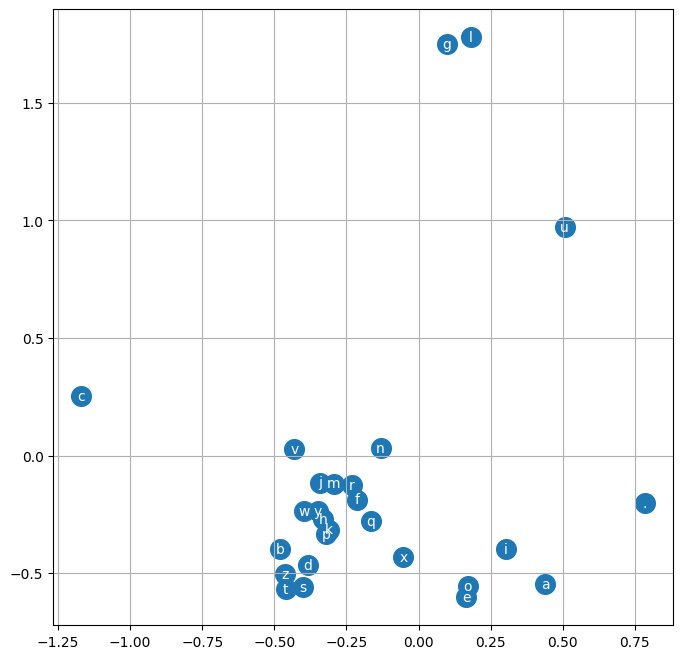

In [360]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

Its fascinating to see how a, e, i and o are closer together as they appear in similar times or fashion in indian names

In [348]:
# Lets try to change some hyperparameters now to see if we can improve model. We have used 2 dimention embedding vector,
# lets try to use 10 dimention now, We can also try some other options like increasing hidden layers to 300

In [361]:
# Let again initilise everything, Now we know, we will use 10 dimentions in C

C, W1, b1, W2, b2, parameters = initilise_model(embedding_dims=10)

Model initilised..
Hidden Layers : 100, embedding_dims : 10, input_values 27, output_values: 27
Number of parameters in model 6097


In [362]:
# Lets run for 30000 iterations
for i in range(30000):
  # Forward pass

  ix = torch.randint(0,Xtr.shape[0], (100,)) # We will form minibatch using this

  emb = C[Xtr[ix]] # (37,3, 2)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (37,100)
  logits = h @ W2 + b2 # 37,27
  # loss
  loss = F.cross_entropy(logits, Ytr[ix])

  # Backward pass
  for p in parameters:
    p.grad = None

  loss.backward()

  lr = 0.1 if i < 20000 else 0.01
  # Update parameters
  for p in parameters:
      p.data += -lr * p.grad


print(loss)

tensor(1.8602, grad_fn=<NllLossBackward0>)


In [363]:
# Loss is good now
# Lets check for whole Xdev
  # Print loss for all of Xdev
emb = C[Xdev] # (37,3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (37,100)
logits = h @ W2 + b2 # 37,27
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.0348, grad_fn=<NllLossBackward0>)

In [364]:
# Lets try now same on test set

emb = C[Xte] # (37,3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (37,100)
logits = h @ W2 + b2 # 37,27
loss = F.cross_entropy(logits, Yte)
loss

tensor(2.0260, grad_fn=<NllLossBackward0>)

In [367]:
# Lets now Sample from our model

g = torch.Generator().manual_seed(2147483647 + 102) # for reproducability

for _ in range(20):

  out = []
  context = [0] * block_size # Initilise with all ...
  while True:
    emb = C[torch.tensor([context])] # (1, block_size, d)
    h = torch.tanh(emb.view(1, -1) @ W1 + b1) # (37,100)
    logits = h @ W2 + b2 # 37,27
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1, generator=g).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break

  print(''.join(itos[i] for i in out))

dharshini.
havatri.
yahan.
jantthg.
seeytheeshika.
cakbishamumani.
abhuladh.
chanthan.
ckaya.
akiyai.
kalath.
mathesh.
kaarejulzhakka.
masadheka.
shrirata.
sajan.
akulup.
sanan.
sarkena.
virute.
